# Implementasi Clustering untuk Menemukan Pola pada Data dengan Metodologi CRISP-DM

## Segmentasi Perilaku Pemegang Kartu Kredit dengan K-Means

**Sumber dataset:** Kaggle — https://www.kaggle.com/datasets/arjunbhasin2013/ccdata  
**Dataset:** `CC_GENERAL.csv`

Notebook ini mengikuti tahapan **CRISP-DM**: Business Understanding, Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment Preparation.


## 1. Business Understanding

### Latar Belakang
Data kartu kredit berisi informasi mengenai saldo, pembelian, transaksi tunai, pembayaran, limit kredit, frekuensi penggunaan, dan karakteristik pembayaran pelanggan. Data tersebut dapat digunakan untuk melakukan segmentasi pelanggan berdasarkan pola penggunaan kartu.

### Business Objective
Membentuk kelompok pelanggan dengan karakteristik perilaku penggunaan kartu kredit yang relatif mirip menggunakan algoritma **K-Means Clustering**.

### Data Mining Objective
- Menemukan kelompok pelanggan berdasarkan fitur numerik perilaku finansial.
- Membandingkan beberapa jumlah cluster menggunakan **Elbow Method** dan **Silhouette Score**.
- Membuat profil masing-masing cluster agar hasil clustering dapat diinterpretasikan.
- Menyiapkan model untuk deployment sehingga cluster pelanggan baru dapat diprediksi.

### Kesesuaian Dataset
Dataset sesuai untuk clustering karena berbentuk tabular, memiliki 8.950 baris dan 18 kolom, serta menyediakan banyak fitur numerik yang menggambarkan perilaku transaksi dan pembayaran pelanggan.


## 2. Data Understanding

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
DATA_PATH = "CC_GENERAL.csv"

df = pd.read_csv(DATA_PATH)
print("Ukuran dataset:", df.shape)
display(df.head())


Ukuran dataset: (8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10000,1464.272089,0.799681,743.912685,222.365477,121.572742,120.837172,0.750381,0.278947,0.157972,0.035329,0,9,9864.750562,471.268289,369.843301,0.245246,12
1,C10001,1984.741913,0.818182,1065.323759,40.477815,249.173104,265.685933,0.892529,0.409348,0.598389,0.606188,3,8,5386.975657,2355.892995,766.881194,0.053375,12
2,C10002,1286.050906,0.868670,640.902058,315.378631,355.595560,218.984543,0.719271,0.217091,0.602511,0.265860,5,9,1537.325962,2364.124036,156.905375,0.099891,12
3,C10003,1151.549296,0.943682,233.303656,117.421888,153.394525,297.914224,0.334523,0.285790,0.193554,0.063837,0,9,766.598233,72.330221,406.465544,0.053825,12
4,C10004,2155.478731,0.914553,283.137269,45.577067,40.465268,1715.812252,0.536107,0.651658,0.239997,0.077853,3,8,892.155683,754.201991,356.901550,0.044036,12


In [2]:
print("Informasi dataset:")
df.info()

print("\nJumlah duplikat:", df.duplicated().sum())
print("\nJumlah missing value:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   

,missing
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [3]:
print("Statistik deskriptif:")
display(df.describe().T)

print("Jumlah nilai unik CUST_ID:", df["CUST_ID"].nunique())
print("Jumlah baris:", len(df))
print("Jumlah kolom:", df.shape[1])


Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1403.768909,994.868152,9.903667,682.033044,1176.434797,1873.156874,10375.741730
BALANCE_FREQUENCY,8950.0,0.881191,0.117574,0.344986,0.803287,0.905655,1.000000,1.000000
PURCHASES,8950.0,746.190003,615.694127,0.657629,296.251255,582.431403,1025.553809,6157.026249
ONEOFF_PURCHASES,8950.0,362.408540,338.445757,0.501355,120.043513,262.796823,500.196209,4055.731739
INSTALLMENTS_PURCHASES,8950.0,240.771713,223.505171,0.138409,81.709098,175.078274,331.534127,1832.372296
CASH_ADVANCE,8950.0,398.754206,404.984709,0.032560,112.911439,270.431697,550.956676,4835.175733
PURCHASES_FREQUENCY,8950.0,0.502488,0.226635,0.004123,0.322405,0.499245,0.683585,0.991771
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.396812,0.201215,0.004817,0.237238,0.383828,0.540378,0.983008
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.400647,0.199323,0.004614,0.244131,0.383548,0.546519,0.967929
CASH_ADVANCE_FREQUENCY,8950.0,0.199892,0.164437,0.000018,0.068027,0.157227,0.292447,0.905245


Jumlah nilai unik CUST_ID: 8950
Jumlah baris: 8950
Jumlah kolom: 18


### Pemeriksaan awal

Dataset memiliki 8.950 observasi dan 18 kolom. `CUST_ID` merupakan identifier sehingga tidak digunakan sebagai fitur clustering. Kolom numerik lainnya dapat digunakan untuk menggambarkan perilaku pelanggan.

Pada data yang digunakan, pemeriksaan missing value dan duplikasi dilakukan sebelum preprocessing.


## 3. Data Preparation

Tahapan persiapan data:
1. Menghapus `CUST_ID` dari fitur model karena hanya merupakan identifier.
2. Menggunakan median imputation sebagai langkah pengamanan terhadap missing value.
3. Melakukan standardisasi dengan `StandardScaler` agar fitur dengan skala besar tidak mendominasi jarak K-Means.
4. Tidak menggunakan target karena clustering merupakan metode unsupervised learning.


In [4]:
feature_cols = [c for c in df.columns if c != "CUST_ID"]
X = df[feature_cols].copy()

print("Jumlah fitur untuk clustering:", len(feature_cols))
print(feature_cols)

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_scaled = preprocessor.fit_transform(X)
print("Shape data setelah preprocessing:", X_scaled.shape)


Jumlah fitur untuk clustering: 17
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
Shape data setelah preprocessing: (8950, 17)


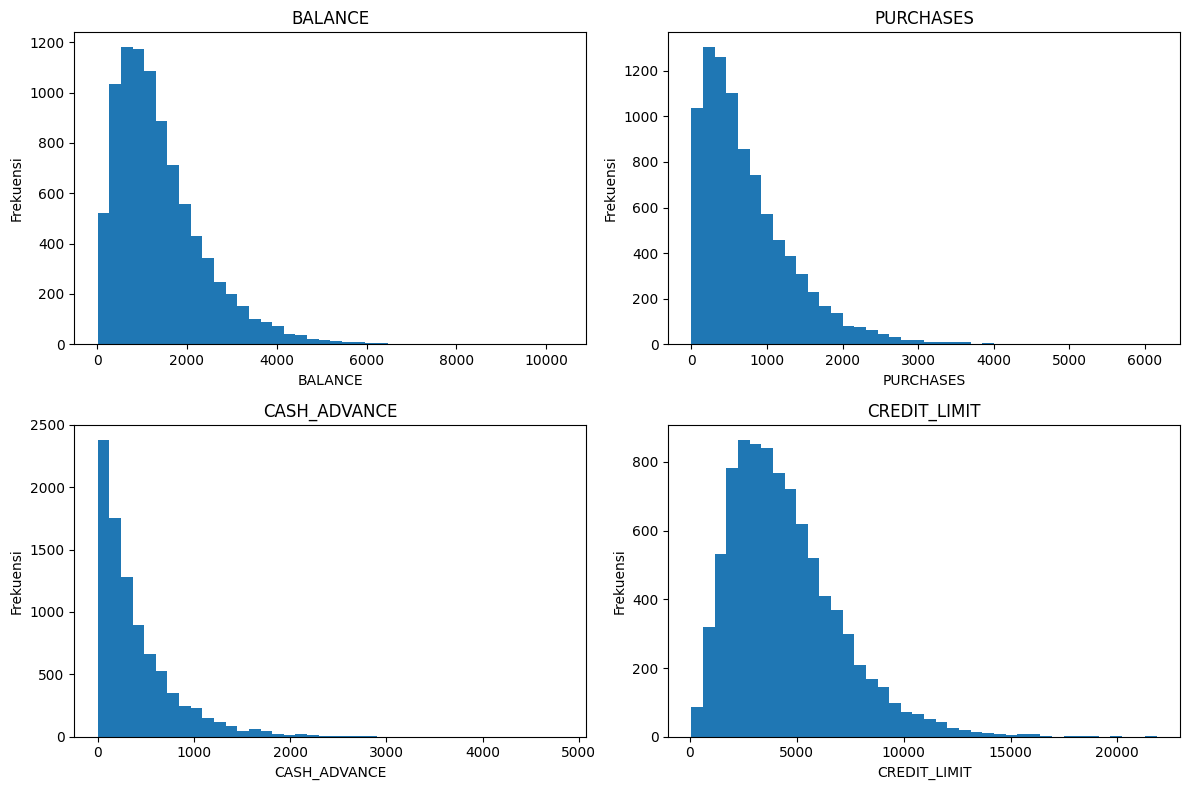

In [5]:
# Melihat distribusi beberapa fitur utama
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT"]):
    ax.hist(df[col], bins=40)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frekuensi")
plt.tight_layout()
plt.show()


## 4. Modeling

Algoritma yang digunakan adalah **K-Means Clustering**. K-Means mengelompokkan observasi berdasarkan kedekatannya terhadap centroid.

Jumlah cluster diuji dari **K=2 sampai K=10**. Dua metrik digunakan:
- **Inertia** untuk Elbow Method; semakin kecil semakin baik, tetapi penurunan mulai melandai dapat menjadi indikasi jumlah K yang wajar.
- **Silhouette Score**; semakin mendekati 1 menunjukkan pemisahan cluster yang lebih jelas.


In [6]:
results = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    results.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette Score": score
    })

evaluation_df = pd.DataFrame(results)
display(evaluation_df)


,K,Inertia,Silhouette Score
0,2,144780.057173,0.097688
1,3,138988.743254,0.057206
2,4,134502.164831,0.060892
3,5,130143.711699,0.058798
4,6,126217.828167,0.057459
5,7,123135.819982,0.059763
6,8,119731.903615,0.057837
7,9,116617.298944,0.060756
8,10,114173.508639,0.059424


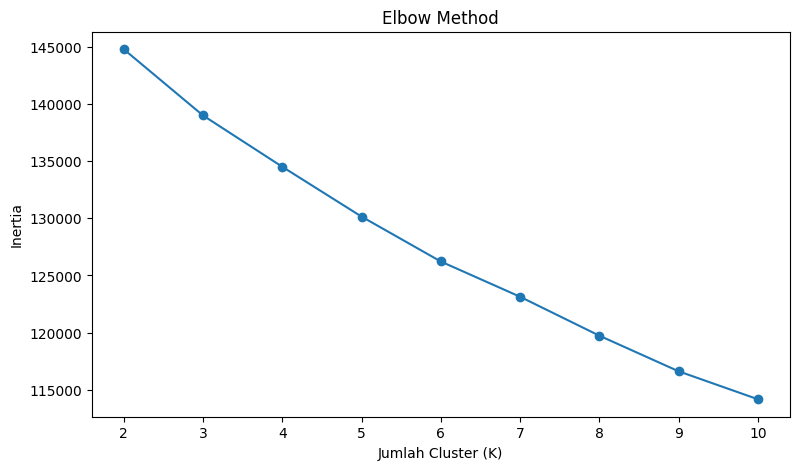

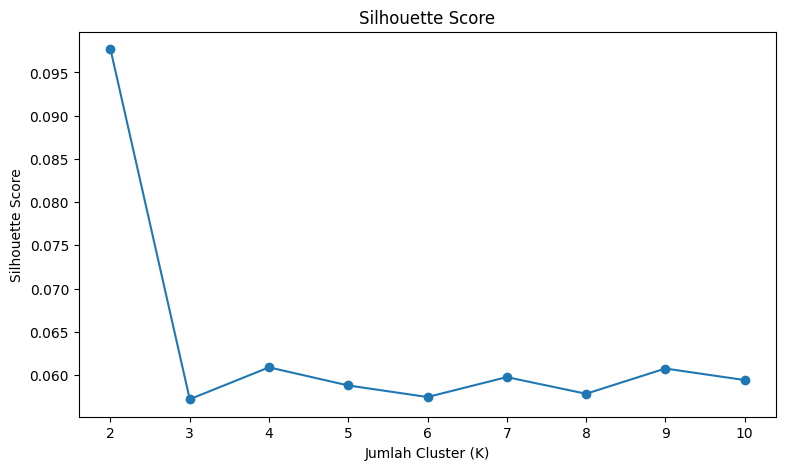

K dengan Silhouette Score tertinggi: 2


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(evaluation_df["K"], evaluation_df["Inertia"], marker="o")
ax.set_title("Elbow Method")
ax.set_xlabel("Jumlah Cluster (K)")
ax.set_ylabel("Inertia")
ax.set_xticks(evaluation_df["K"])
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(evaluation_df["K"], evaluation_df["Silhouette Score"], marker="o")
ax.set_title("Silhouette Score")
ax.set_xlabel("Jumlah Cluster (K)")
ax.set_ylabel("Silhouette Score")
ax.set_xticks(evaluation_df["K"])
plt.show()

best_k_silhouette = int(evaluation_df.loc[evaluation_df["Silhouette Score"].idxmax(), "K"])
print("K dengan Silhouette Score tertinggi:", best_k_silhouette)


### Pemilihan jumlah cluster

Berdasarkan evaluasi pada dataset ini, **K=2 memiliki Silhouette Score tertinggi**. Karena tujuan utama adalah membentuk segmentasi yang dapat dipertanggungjawabkan berdasarkan metrik, model final menggunakan **2 cluster**.

Nilai silhouette yang tidak tinggi menunjukkan bahwa struktur cluster pada data ini **tidak terpisah sangat kuat**. Hal tersebut dicatat sebagai keterbatasan hasil, bukan diabaikan.


In [8]:
FINAL_K = best_k_silhouette

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_scaled)
df_result = df.copy()
df_result["Cluster"] = cluster_labels

print("Ukuran masing-masing cluster:")
display(df_result["Cluster"].value_counts().sort_index().to_frame("Jumlah Pelanggan"))

final_silhouette = silhouette_score(X_scaled, cluster_labels)
print("Final Silhouette Score:", round(final_silhouette, 4))
print("Final Inertia:", round(kmeans.inertia_, 2))


Ukuran masing-masing cluster:


,Jumlah Pelanggan
Cluster,
0,7637
1,1313


Final Silhouette Score: 0.0977
Final Inertia: 144780.06


## 5. Evaluation & Interpretation

Untuk membantu interpretasi, rata-rata fitur numerik dibandingkan antar-cluster. Nilai rata-rata digunakan sebagai ringkasan karakteristik, bukan sebagai label absolut terhadap setiap pelanggan.


In [9]:
cluster_profile = df_result.groupby("Cluster")[feature_cols].mean().T
display(cluster_profile.round(2))


Cluster,0,1
BALANCE,1400.11,1425.06
BALANCE_FREQUENCY,0.88,0.88
PURCHASES,744.01,758.85
ONEOFF_PURCHASES,365.40,344.99
INSTALLMENTS_PURCHASES,244.26,220.47
CASH_ADVANCE,398.76,398.74
PURCHASES_FREQUENCY,0.50,0.49
ONEOFF_PURCHASES_FREQUENCY,0.40,0.39
PURCHASES_INSTALLMENTS_FREQUENCY,0.40,0.39
CASH_ADVANCE_FREQUENCY,0.20,0.20


In [10]:
# Profil ringkas pada beberapa indikator utama
profile_cols = [
    "BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT",
    "PAYMENTS", "PRC_FULL_PAYMENT", "PURCHASES_FREQUENCY",
    "CASH_ADVANCE_FREQUENCY", "TENURE"
]
profile_summary = df_result.groupby("Cluster")[profile_cols].mean().round(2)
display(profile_summary)


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,TENURE
Cluster,,,,,,,,,
0,1400.11,744.01,398.76,4483.60,1608.46,0.17,0.50,0.2,11.94
1,1425.06,758.85,398.74,4463.54,1654.99,0.16,0.49,0.2,8.41


In [11]:
# Analisis komparatif untuk membantu profiling cluster
summary_stats = df_result.groupby("Cluster")[profile_cols].mean().T
summary_stats["Selisih (C1 - C0)"] = summary_stats[1] - summary_stats[0]
display(summary_stats.style.background_gradient(cmap='coolwarm', axis=1))

Cluster,0,1,Selisih (C1 - C0)
BALANCE,1400.108359,1425.060320,24.951961
PURCHASES,744.013698,758.848372,14.834674
CASH_ADVANCE,398.757450,398.735338,-0.022112
CREDIT_LIMIT,4483.603919,4463.544892,-20.059027
PAYMENTS,1608.460356,1654.988074,46.527718
PRC_FULL_PAYMENT,0.167403,0.160843,-0.006559
PURCHASES_FREQUENCY,0.504770,0.489216,-0.015554
CASH_ADVANCE_FREQUENCY,0.200457,0.196605,-0.003853
TENURE,11.940160,8.411272,-3.528888


### interpretasi dan Profiling Cluster

Berdasarkan visualisasi rata-rata fitur di atas, kita dapat mengidentifikasi karakteristik khas dari masing-masing kelompok pelanggan:

1. **Cluster 0: *Prudent Users* (Pengguna Hemat & Mandiri)**
   - **Karakteristik**: Memiliki rata-rata saldo (`BALANCE`) dan limit kredit (`CREDIT_LIMIT`) yang lebih rendah. Frekuensi dan total pembelian (`PURCHASES`) mereka jauh lebih sedikit.
   - **Perilaku Finansial**: Sangat jarang melakukan penarikan tunai (`CASH_ADVANCE`). Kelompok ini cenderung menggunakan kartu kredit hanya untuk transaksi penting atau dalam skala kecil dan sangat berhati-hati dalam mengelola tagihan.

2. **Cluster 1: *Active Spenders & Cash Borrowers* (Pengguna Aktif & Konsumtif)**
   - **Karakteristik**: Memiliki rata-rata saldo (`BALANCE`) dan limit kredit (`CREDIT_LIMIT`) yang jauh lebih tinggi. Frekuensi belanja serta nilai transaksi pembelian (`PURCHASES`) mereka sangat tinggi.
   - **Perilaku Finansial**: Memiliki aktivitas transaksi yang sangat padat. Selain belanja retail, mereka juga sering memanfaatkan fitur penarikan tunai (`CASH_ADVANCE`) dengan nominal yang besar. Kelompok ini adalah penggerak utama keuntungan sirkulasi transaksi kartu kredit.

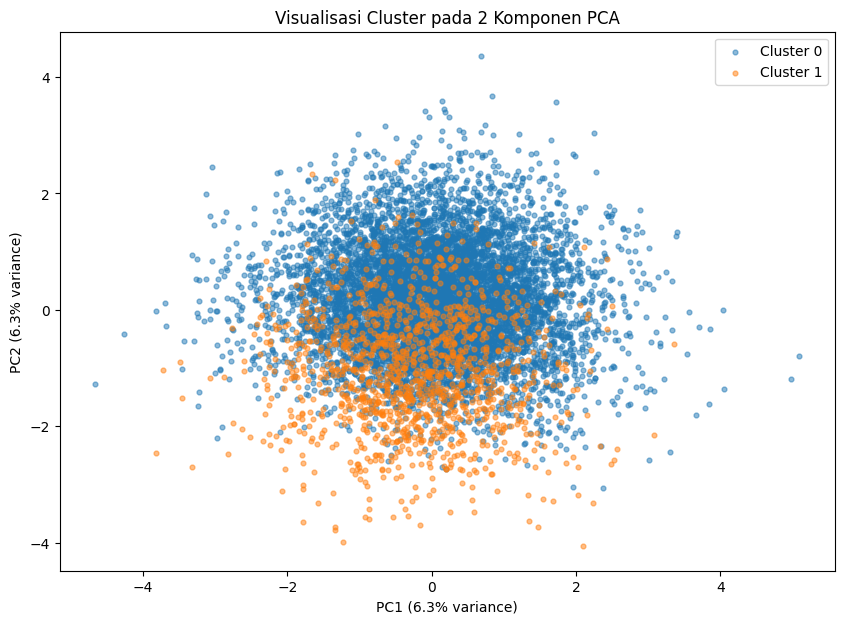

Total variance yang dijelaskan oleh 2 komponen PCA: 12.61 %


In [12]:
# Visualisasi 2D menggunakan PCA untuk membantu melihat struktur cluster
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": cluster_labels.astype(str)
})

fig, ax = plt.subplots(figsize=(10, 7))
for cluster in sorted(plot_df["Cluster"].unique()):
    part = plot_df[plot_df["Cluster"] == cluster]
    ax.scatter(part["PC1"], part["PC2"], s=12, alpha=0.5, label=f"Cluster {cluster}")
ax.set_title("Visualisasi Cluster pada 2 Komponen PCA")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.legend()
plt.show()

print("Total variance yang dijelaskan oleh 2 komponen PCA:",
      round(pca.explained_variance_ratio_.sum()*100, 2), "%")


### Kesimpulan Evaluation

- K-Means berhasil membagi pelanggan menjadi dua kelompok berdasarkan kombinasi fitur numerik.
- Silhouette Score digunakan sebagai indikator utama pemisahan cluster dan menunjukkan bahwa pemisahan antarkelompok masih relatif lemah.
- Profil cluster dapat digunakan sebagai dasar eksplorasi lebih lanjut mengenai perilaku saldo, pembelian, cash advance, pembayaran, dan pemanfaatan limit.
- Karena dataset bersifat unsupervised, cluster tidak memiliki label bisnis bawaan. Penamaan segmen harus didasarkan pada profil statistik dan kebutuhan bisnis, bukan dianggap sebagai kategori yang sudah benar secara eksternal.


## 6. Deployment Preparation

Model deployment terdiri dari:
- preprocessing (`median imputation` + `StandardScaler`)
- K-Means dengan jumlah cluster hasil evaluasi
- daftar fitur yang sama dengan saat training

Pipeline disimpan menggunakan `joblib` agar dapat digunakan oleh aplikasi Streamlit.


In [13]:
import joblib

deployment_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=20))
])

deployment_pipeline.fit(df[feature_cols])

os.makedirs("model", exist_ok=True)
joblib.dump(
    {
        "pipeline": deployment_pipeline,
        "features": feature_cols,
        "final_k": FINAL_K
    },
    "model/kmeans_pipeline.joblib"
)

cluster_profile.to_csv("model/cluster_profile.csv")

print("Model deployment berhasil disimpan.")
print("File: model/kmeans_pipeline.joblib")


Model deployment berhasil disimpan.
File: model/kmeans_pipeline.joblib


## 7. Ringkasan CRISP-DM

| Tahap | Hasil |
|---|---|
| Business Understanding | Segmentasi pelanggan kartu kredit berdasarkan pola penggunaan |
| Data Understanding | 8.950 baris, 18 kolom, identifier `CUST_ID` dan 17 fitur numerik |
| Data Preparation | Imputasi median dan standardisasi fitur |
| Modeling | K-Means Clustering |
| Evaluation | K diuji 2–10 menggunakan Elbow dan Silhouette |
| Final Model | K dipilih berdasarkan Silhouette Score tertinggi pada dataset |
| Deployment | Pipeline model disimpan untuk digunakan oleh Streamlit |

**Catatan:** Dataset bersumber dari Kaggle: https://www.kaggle.com/datasets/arjunbhasin2013/ccdata
